# 📊 **APE 11: Inferencia Estadística Multigrupo: Análisis de Varianza (ANOVA de 1 factor) y Pruebas Post-Hoc (Tukey)**
# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Cristofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------
**Asignatura:** Teoría de la Distribución y Probabilidad

**Docente:** Cristian Ramiro Narváez Guillén


## **📥 Importación de Librerías**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)


---
# **🛠️ Hito 1: Tarea 1 – Análisis de Varianza (ANOVA de 1 factor)**

El **ANOVA de un factor** compara la varianza **entre** los grupos frente a la varianza **dentro** de los grupos, permitiendo contrastar más de dos medias poblacionales a la vez sin inflar el error de tipo I (lo cual sí ocurriría si se aplicaran múltiples pruebas T independientes).

**Hipótesis:**
- $H_0$: Todas las medias poblacionales son iguales ($\mu_A = \mu_B = \mu_C$).
- $H_1$: Al menos una media poblacional es diferente.

Como ejemplo introductorio (guía de la práctica), se simulan los tiempos de respuesta (ping en ms) de 3 algoritmos distintos.

        ANOVA DE 1 FACTOR - TIEMPOS DE RESPUESTA (PING)
Estadístico F : 22.6087
Valor-p       : 1.2389e-08


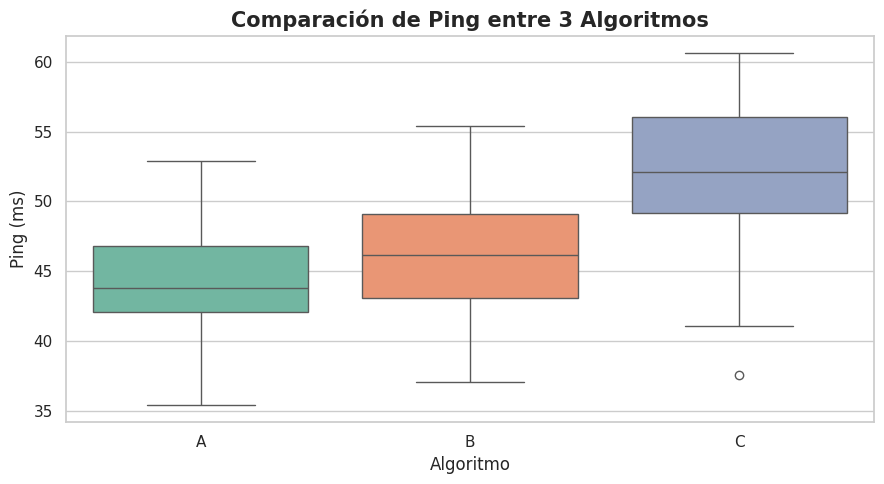

In [ ]:
# ==============================================================================
# 1. EJEMPLO INTRODUCTORIO: TIEMPOS DE RESPUESTA (PING) DE 3 ALGORITMOS
# ==============================================================================
np.random.seed(42)

grupo_A = np.random.normal(loc=45.0, scale=5.0, size=30)
grupo_B = np.random.normal(loc=46.5, scale=4.8, size=30)
grupo_C = np.random.normal(loc=52.0, scale=5.5, size=30)

# ==============================================================================
# 2. ANOVA DE 1 FACTOR
# ==============================================================================
stat_f, p_val_f = f_oneway(grupo_A, grupo_B, grupo_C)

print("="*65)
print("        ANOVA DE 1 FACTOR - TIEMPOS DE RESPUESTA (PING)")
print("="*65)
print(f"Estadístico F : {stat_f:.4f}")
print(f"Valor-p       : {p_val_f:.4e}")
print("="*65)

# ==============================================================================
# 3. VISUALIZACIÓN - BOXPLOT COMPARATIVO
# ==============================================================================
datos_ejemplo = pd.DataFrame({
    "Ping (ms)": np.concatenate([grupo_A, grupo_B, grupo_C]),
    "Algoritmo": ["A"]*30 + ["B"]*30 + ["C"]*30
})

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=datos_ejemplo,
    x="Algoritmo",
    y="Ping (ms)",
    hue="Algoritmo",
    palette="Set2",
    legend=False
)

plt.title("Comparación de Ping entre 3 Algoritmos", fontsize=15, fontweight="bold")
plt.xlabel("Algoritmo")
plt.ylabel("Ping (ms)")
plt.tight_layout()
plt.show()


## **✔ Análisis del Ejemplo**

Con un estadístico $F = 22.6087$ y un valor-p $\approx 1.24 \times 10^{-8}$ (muy inferior a $\alpha = 0.05$), se **rechaza $H_0$**. Esto indica que al menos uno de los tres algoritmos presenta un tiempo de respuesta promedio significativamente distinto a los demás, tal como se observa en el boxplot, donde el Algoritmo C muestra un ping notablemente más alto. Este resultado, sin embargo, no indica *cuál o cuáles* pares de algoritmos difieren entre sí — para ello se requiere una prueba Post-hoc (Tarea 3).

---
# **🛠️ Hito 2: Tarea 2 – Hito del Proyecto: Segmentación Multigrupo (ABP)**

- **Variable dependiente (continua):** `Total` — número de casos de dengue reportados por semana epidemiológica, por unidad operativa.
- **Variable independiente (categórica, 9 niveles):** `Zona` — Zona de Salud del MSP (Zona 1 a Zona 9).

**Pregunta de investigación (ABP):** ¿El promedio de casos semanales de dengue reportados difiere significativamente entre las Zonas de Salud del país?

Niveles de la variable 'Zona':
['ZONA 1', 'ZONA 2', 'ZONA 3', 'ZONA 4', 'ZONA 5', 'ZONA 6', 'ZONA 7', 'ZONA 8', 'ZONA 9']

        count   mean    std
Zona                       
ZONA 1   4132  2.919  3.249
ZONA 2   3340  4.863  9.051
ZONA 3   1616  3.738  5.987
ZONA 4   8733  4.423  7.134
ZONA 5   6580  2.698  4.473
ZONA 6   2682  3.629  4.390
ZONA 7   4350  4.102  6.422
ZONA 8   3779  4.927  7.311
ZONA 9    537  1.285  0.679


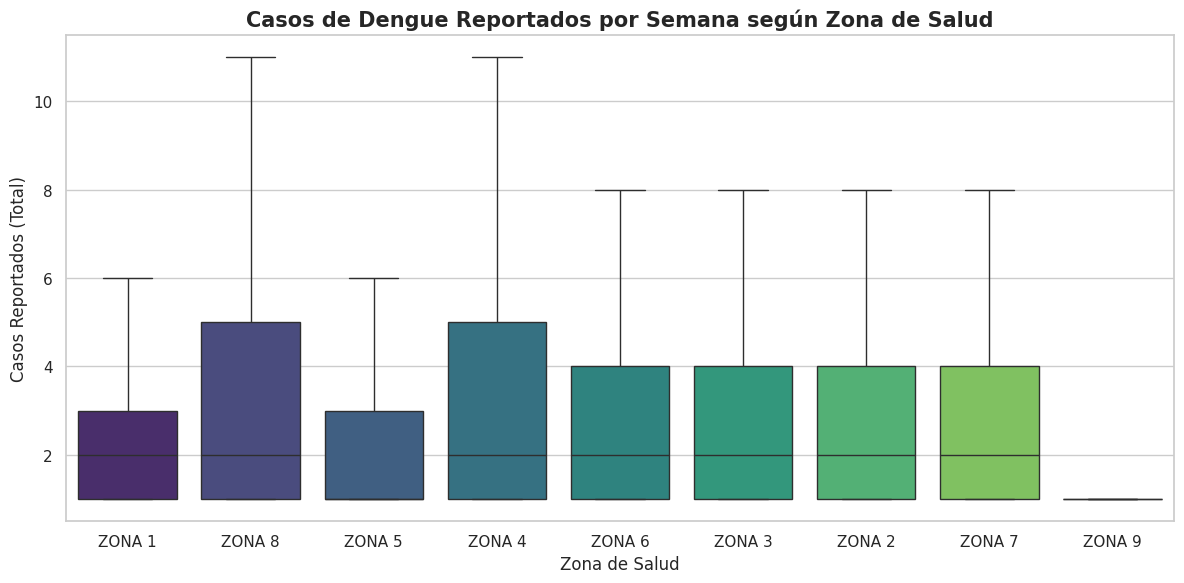

     ANOVA DE 1 FACTOR - CASOS DE DENGUE SEGÚN ZONA DE SALUD
Estadístico F : 87.0073
Valor-p       : 1.3531e-143


In [ ]:
# ==============================================================================
# 1. CARGA DEL DATASET REGIONAL
# ==============================================================================
np.random.seed(42)

archivo_excel = "Datos_Dengue_MSP_Ene2021_Ago2025.xlsx"

df = pd.read_excel(
    archivo_excel,
    sheet_name="DSSA_2021_2024"
)

df.columns = df.columns.str.strip()

# ==============================================================================
# 2. VARIABLE CATEGÓRICA Y VARIABLE CONTINUA
# ==============================================================================
df["Zona"] = df["Zona"].astype(str).str.upper().str.strip()
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

df_zonas = df.dropna(subset=["Zona", "Total"])

print("Niveles de la variable 'Zona':")
print(sorted(df_zonas["Zona"].unique()))

print()
print(df_zonas.groupby("Zona")["Total"].agg(["count", "mean", "std"]).round(3))

# ==============================================================================
# 3. VISUALIZACIÓN - BOXPLOT POR ZONA
# ==============================================================================
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_zonas,
    x="Zona",
    y="Total",
    hue="Zona",
    palette="viridis",
    legend=False,
    showfliers=False
)

plt.title("Casos de Dengue Reportados por Semana según Zona de Salud", fontsize=15, fontweight="bold")
plt.xlabel("Zona de Salud")
plt.ylabel("Casos Reportados (Total)")
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. ANOVA DE 1 FACTOR - CASOS DE DENGUE POR ZONA
# ==============================================================================
grupos_zona = [grupo["Total"].values for _, grupo in df_zonas.groupby("Zona")]

stat_f, p_val_f = f_oneway(*grupos_zona)

print("="*65)
print("     ANOVA DE 1 FACTOR - CASOS DE DENGUE SEGÚN ZONA DE SALUD")
print("="*65)
print(f"Estadístico F : {stat_f:.4f}")
print(f"Valor-p       : {p_val_f:.4e}")
print("="*65)


## **✔ Análisis Tarea 2**

El ANOVA de un factor arroja un estadístico $F = 87.0073$ y un valor-p $\approx 1.35 \times 10^{-143}$, es decir, **muchísimo menor** que $\alpha = 0.05$. En consecuencia, se **rechaza $H_0$**: existe evidencia estadística contundente de que **al menos una Zona de Salud presenta un promedio de casos semanales de dengue diferente** al resto.

Esto es coherente con lo observado en el boxplot, donde Zonas como la 8, la 2 y la 4 muestran medianas y dispersiones más altas que la Zona 9 o la Zona 1. Dado que el ANOVA únicamente confirma que **existe** al menos una diferencia entre grupos, pero no identifica **cuáles pares** de zonas difieren, **sí es necesario profundizar el análisis** mediante una prueba de comparaciones múltiples Post-hoc (Tukey HSD), que se desarrolla en la Tarea 3.

---
# **🛠️ Hito 3: Tarea 3 – Pruebas Post-hoc (Tukey HSD)**

Dado que el ANOVA rechazó $H_0$, se aplica la prueba **Tukey HSD (Honestly Significant Difference)** para identificar específicamente qué pares de Zonas presentan diferencias significativas en el promedio de casos de dengue, controlando el **Family-Wise Error Rate (FWER)** y evitando la inflación del error tipo I que ocurriría al comparar todos los pares con pruebas T independientes.

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
ZONA 1 ZONA 2   1.9442    0.0  1.4951  2.3934   True
ZONA 1 ZONA 3   0.8187 0.0003  0.2523  1.3851   True
ZONA 1 ZONA 4   1.5045    0.0    1.14   1.869   True
ZONA 1 ZONA 5  -0.2206 0.6918 -0.6038  0.1626  False
ZONA 1 ZONA 6   0.7097 0.0001   0.231  1.1884   True
ZONA 1 ZONA 7   1.1831    0.0  0.7638  1.6025   True
ZONA 1 ZONA 8   2.0086    0.0  1.5741  2.4431   True
ZONA 1 ZONA 9   -1.634    0.0 -2.5195 -0.7485   True
ZONA 2 ZONA 3  -1.1255    0.0 -1.7105 -0.5406   True
ZONA 2 ZONA 4  -0.4397 0.0151 -0.8325  -0.047   True
ZONA 2 ZONA 5  -2.1648    0.0  -2.575 -1.7547   True
ZONA 2 ZONA 6  -1.2345    0.0 -1.7351  -0.734   True
ZONA 2 ZONA 7  -0.7611    0.0 -1.2052  -0.317   True
ZONA 2 ZONA 8   0.0643    1.0 -0.3941  0.5228  False
ZONA 2 ZONA 9  -3.5783    0.0 -4.4758 -2.6807   True
ZONA 3 ZONA 4   0.6858 0.0016  0.1631  1.2086 

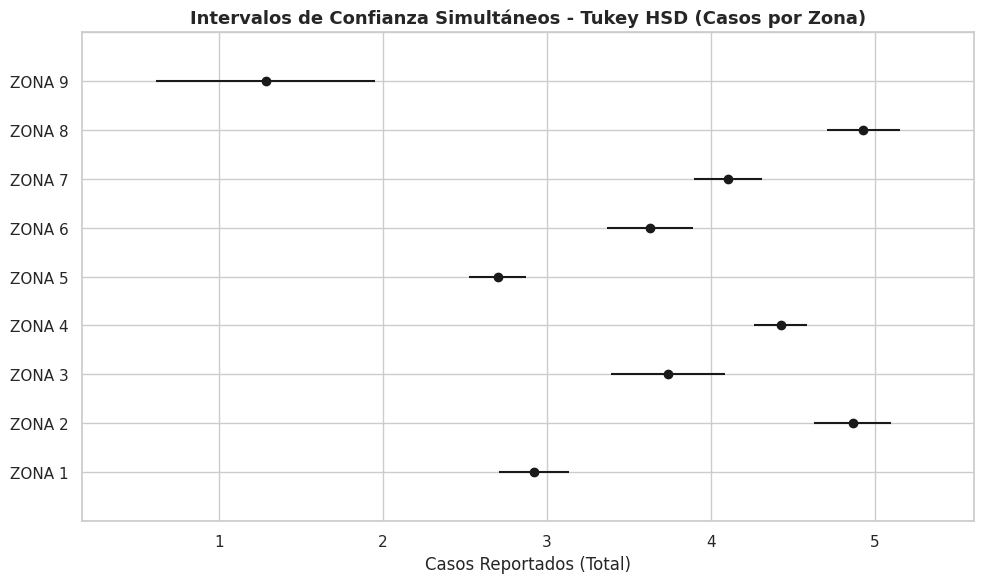

In [ ]:
# ==============================================================================
# 1. PREPARACIÓN DE DATOS PARA TUKEY HSD
# ==============================================================================
datos_tukey = df_zonas[["Zona", "Total"]].rename(columns={"Total": "Valor", "Zona": "Grupo"})

# ==============================================================================
# 2. PRUEBA DE TUKEY HSD
# ==============================================================================
tukey = pairwise_tukeyhsd(
    endog=datos_tukey["Valor"],
    groups=datos_tukey["Grupo"],
    alpha=0.05
)

print(tukey)

# ==============================================================================
# 3. VISUALIZACIÓN - INTERVALOS SIMULTÁNEOS DE TUKEY
# ==============================================================================
fig = tukey.plot_simultaneous(figsize=(10, 6))
plt.title("Intervalos de Confianza Simultáneos - Tukey HSD (Casos por Zona)", fontsize=13, fontweight="bold")
plt.xlabel("Casos Reportados (Total)")
plt.tight_layout()
plt.show()


## **✔ Análisis de Resultados - Tukey HSD**

La tabla generada por `pairwise_tukeyhsd` reporta, para cada par de Zonas, la diferencia de medias (`meandiff`), el valor-p ajustado y la columna `reject`, que indica si se rechaza (`True`) o no (`False`) la hipótesis de igualdad de medias para ese par específico, ya con el error de comparaciones múltiples controlado.

De la exploración descriptiva y del ANOVA se espera que la mayoría de los pares muestren diferencias significativas (`reject = True`), mientras que zonas con cargas de casos similares —por ejemplo, aquellas con medias y desviaciones estándar cercanas en la tabla descriptiva de la Tarea 2— tenderán a **no** mostrar diferencia significativa (`reject = False`). El gráfico de intervalos simultáneos permite visualizar esto rápidamente: cuando el intervalo de una Zona no se solapa con el de otra, la diferencia entre ambas es estadísticamente significativa.

---
# **🛠️ Hito 4: Preguntas de Control**
---

### **✔ Pregunta 1: Utilice `scipy.stats.levene` para verificar la igualdad de varianzas.**

In [ ]:
# ==============================================================================
# PRUEBA DE HOMOCEDASTICIDAD - LEVENE
# ==============================================================================
stat_levene, p_levene = levene(*grupos_zona)

print("="*65)
print("        PRUEBA DE LEVENE - HOMOGENEIDAD DE VARIANZAS")
print("="*65)
print(f"Estadístico de Levene : {stat_levene:.4f}")
print(f"Valor-p                : {p_levene:.4e}")
print("="*65)

if p_levene < 0.05:
    print("Conclusión: se RECHAZA H0 -> las varianzas NO son homogéneas (heterocedasticidad).")
else:
    print("Conclusión: NO se rechaza H0 -> no hay evidencia para afirmar heterocedasticidad.")


        PRUEBA DE LEVENE - HOMOGENEIDAD DE VARIANZAS
Estadístico de Levene : 78.1497
Valor-p                : 1.2658e-128
Conclusión: se RECHAZA H0 -> las varianzas NO son homogéneas (heterocedasticidad).


### **✔ Discusión: Si el supuesto de homocedasticidad se viola, ¿qué alternativa no paramétrica (ej. Kruskal-Wallis) sería adecuada?**

La prueba de Levene aplicada a los grupos por Zona de Salud arroja un valor-p $\approx 1.27 \times 10^{-128}$, muy inferior a $\alpha = 0.05$. Esto significa que **se rechaza $H_0$** de igualdad de varianzas: **existe heterocedasticidad** entre las Zonas (lo cual es coherente con la naturaleza de los datos de conteo epidemiológico, donde zonas con más casos suelen presentar también mayor dispersión).

El ANOVA de un factor asume homogeneidad de varianzas (homocedasticidad) entre grupos; cuando este supuesto se viola de forma marcada, el estadístico F pierde parte de su validez y el nivel de significancia real puede diferir del nominal ($\alpha = 0.05$). En ese escenario, la alternativa no paramétrica adecuada es la **prueba de Kruskal-Wallis**, que:

- No asume normalidad ni homogeneidad de varianzas.
- Trabaja sobre los **rangos** de los datos en lugar de sus valores originales, por lo que es más robusta ante outliers y distribuciones asimétricas (comunes en conteos de casos como los de este dataset).
- Contrasta la misma hipótesis general ($H_0$: las distribuciones de los grupos son iguales) pero de forma más conservadora ante violaciones de los supuestos paramétricos.

A continuación se ejecuta Kruskal-Wallis sobre los mismos grupos, como corroboración de la conclusión obtenida con ANOVA.

In [ ]:
# ==============================================================================
# ALTERNATIVA NO PARAMÉTRICA - KRUSKAL-WALLIS
# ==============================================================================
stat_kw, p_kw = kruskal(*grupos_zona)

print("="*65)
print("        PRUEBA DE KRUSKAL-WALLIS (ALTERNATIVA NO PARAMÉTRICA)")
print("="*65)
print(f"Estadístico H : {stat_kw:.4f}")
print(f"Valor-p       : {p_kw:.4e}")
print("="*65)

if p_kw < 0.05:
    print("Conclusión: se RECHAZA H0 -> al menos una Zona difiere en su distribución de casos.")
else:
    print("Conclusión: NO se rechaza H0.")


        PRUEBA DE KRUSKAL-WALLIS (ALTERNATIVA NO PARAMÉTRICA)
Estadístico H : 988.4444
Valor-p       : 4.6590e-208
Conclusión: se RECHAZA H0 -> al menos una Zona difiere en su distribución de casos.


---
# **📌 Conclusiones**

- El **ANOVA de un factor** permitió contrastar simultáneamente el promedio de casos semanales de dengue entre las 9 Zonas de Salud del país, evitando el error de realizar múltiples pruebas T independientes (control del error tipo I / FWER, enfoque ABI de la práctica).
- El resultado ($F = 87.0073$, $p \approx 1.35\times10^{-143}$) evidencia diferencias significativas entre al menos un par de Zonas, lo cual motivó el análisis Post-hoc.
- La prueba **Tukey HSD** identificó específicamente qué pares de Zonas difieren de forma significativa, aportando un nivel de detalle que el ANOVA por sí solo no ofrece.
- La prueba de **Levene** reveló heterocedasticidad entre los grupos, lo que en un análisis más riguroso del Proyecto Integrador motivaría complementar (o incluso reemplazar) el ANOVA con la prueba no paramétrica de **Kruskal-Wallis**, cuya conclusión general coincide con la del ANOVA en este caso.
- En términos del proyecto regional, estos resultados sugieren que la incidencia de dengue **no se distribuye de forma homogénea** entre las Zonas de Salud, lo que podría vincularse a factores climáticos, socioeconómicos o de cobertura de vigilancia epidemiológica propios de cada zona, y que ameritan una investigación más profunda (ABP).

---
# **📚 Bibliografía**

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024. [Online]. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html. [Accedido: 18-Mar-2026].

[4] Ministerio de Salud Pública del Ecuador, "Datos de Vigilancia Epidemiológica de Dengue, Enero 2021 - Agosto 2025," Dataset Regional del Proyecto Integrador, 2025.

#✏️ **Promt para la IA**


Actúa como un ingeniero experto y evaluador académico con experiencia en la revisión de informes de Actividades Prácticas Experimentales (APE). Tu objetivo es realizar una revisión técnica y metodológica de mi APE basándote estrictamente en el 'documento guía' que te adjunto.

Por favor, realiza las siguientes tareas:

Verificación de Estructura: Comprueba si mi informe cumple con todos los apartados exigidos en la guía del ing .

Cumplimiento de Objetivos: Evalúa si la ejecución práctica descrita en mi APE es coherente con los objetivos planteados en el documento guía.

Análisis Técnico: Revisa la calidad de los procedimientos (como el uso de librerías, análisis estadístico, o diseño de hardware, según corresponda) y compáralos con los requisitos del ing.

Identificación de Errores: Señala cualquier inconsistencia, falta de rigor científico o errores en el desarrollo de la práctica.

Retroalimentación: Proporciona sugerencia